Author: Joel Minj
OpenMC 0.15.1 | Python 3.13.2 | Activity 5

In [1]:

import glob
import logging
import os
from math import log10, pi
import matplotlib.pyplot as plt
import numpy as np
import openmc
import openmc.mgxs as mgxs
import pandas as pd

In [ ]:
# Configure cross-sections and logging
openmc.config['cross_sections'] = 'cross_sections.xml'
logging.basicConfig(level=logging.INFO)

In [3]:
# Cleanup function
def safe_remove(file_patterns):
    for pattern in file_patterns:
        for f in glob.glob(pattern):
            try:
                os.remove(f)
                logging.info(f"Removed {f}")
            except Exception as e:
                logging.warning(f"Error removing {f}: {str(e)}")

safe_remove(['*.xml', '*.h5', '*.out', '*.png'])


In [4]:
model = openmc.Model()

In [5]:
M_U = openmc.data.atomic_weight('U')
M_O = openmc.data.atomic_weight('O')
M_H = openmc.data.atomic_weight('H')
M_F = 2*M_O + M_U
M_M = 2*M_H + M_O

m_F = 70.44e6   # Mass of fuel (UO2)
T = 326.85+273.15    # Temperature in K
p = 155              # Pressure in bar

density_F = 10.0701
density_M = openmc.data.water_density(T, 15.5)  # Density in g/cm^3 (pressure in MPa)

HU=4 # Volume moderator / Volume fuel = 4

V_F = m_F/density_F
V_M = HU*V_F
V_T = V_F+V_M

m_M = HU*(density_M/density_F)*m_F

w_U = (M_U/M_F)*m_F/(m_F+m_M)
w_O = (2*(M_O/M_F)*m_F + (M_O/M_M)*m_M) / (m_F+m_M)
w_H = 2*(M_H/M_M)*m_M/(m_F+m_M)

density_mix = (m_F+m_M) / (V_F+V_M)

radius = ((3/4)*V_T/np.pi)**(1/3)

mix = openmc.Material()
mix.name = 'Mix of moderator and fuel'
mix.set_density('g/cm3', density_mix)
mix.temperature = T
mix.id = 101
mix.add_element('U', w_U, 'wo', 5) # Enrichment 5%
mix.add_element('O', w_O, 'wo')
mix.add_element('H', w_H, 'wo')

model.materials = openmc.Materials([mix])

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

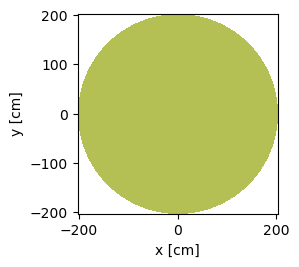

In [6]:
sphere_surface = openmc.Sphere (r=radius)
sphere_surface.id = 102
sphere_surface.boundary_type = 'reflective'

sphere_cell = openmc.Cell (fill = mix)
sphere_cell.id =103
sphere_cell.region = -sphere_surface

sphere = openmc.Universe()
sphere.od = 104
sphere.add_cells([sphere_cell])

model.geometry = openmc.Geometry(sphere)

# Graphic of the geometry. 

sphere.plot(origin=(0, 0 , 0), 
            width=(radius*2, radius*2),
            pixels=(200, 200),
            basis='xy',
            color_by='material')

In [7]:
settings = openmc.Settings()
settings.temperature = {'method': 'interpolation'}
settings.run_mode = 'eigenvalue'
settings.particles = 1000		
settings.batches = 1000			
settings.inactive = 50

lower_left = (-radius, -radius, -radius)
upper_right = (radius, radius, radius)
uniform_dist = openmc.stats.Box(lower_left, upper_right, only_fissionable=True)
settings.source = openmc.source.Source(space=uniform_dist)

model.settings = settings

/home/joelminj/anaconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/stats/multivariate.py:829: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "
/home/joelminj/anaconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/source.py:656: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn("This class is deprecated in favor of 'IndependentSource'", FutureWarning)


In [8]:
#  2-group EnergyGroups object
groups = openmc.mgxs.EnergyGroups([0., 0.625, 20.0e6])


mgxs_lib = openmc.mgxs.Library(model.geometry)
mgxs_lib.energy_groups = groups

# multi-group cross section types to compute
mgxs_lib.mgxs_types = ['total', 'absorption', 'nu-fission', 'fission',
                       'nu-scatter matrix', 'multiplicity matrix', 'chi']

mgxs_lib.domain_type = "material"
mgxs_lib.domains = model.geometry.get_all_materials().values()
mgxs_lib.by_nuclide = False
mgxs_lib.legendre_order = 3
mgxs_lib.check_library_for_openmc_mgxs()
mgxs_lib.build_library()

# tallies
tallies = openmc.Tallies()

mgxs_lib.add_to_tallies_file(tallies, merge=True)

e_min, e_max = 1e-5, 20.0e6
groups = 500
energies = np.logspace(log10(e_min), log10(e_max), groups + 1)
energy_filter = openmc.EnergyFilter(energies)

spectrum_tally = openmc.Tally(name='Flux_spectrum')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']
tallies.append(spectrum_tally)

model.tallies = tallies


/home/joelminj/anaconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mgxs/library.py:401: RuntimeWarning: The P0 correction will be ignored since the scattering order 3 is greater than zero
  warn(msg, RuntimeWarning)


In [9]:
statepoint_file = model.run()

/home/joelminj/anaconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=1.
  warn(msg, IDWarning)
/home/joelminj/anaconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=2.
  warn(msg, IDWarning)
/home/joelminj/anaconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=11.
  warn(msg, IDWarning)


[studiojkm:07105] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.studiojkm.1000/jf.0/619315200/shared_mem_cuda_pool.studiojkm could be created.
[studiojkm:07105] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
       

In [10]:
sp = openmc.StatePoint(statepoint_file)
keff=sp.keff.nominal_value

print(keff)
print(radius)


1.4243595059910945
202.87209762698208


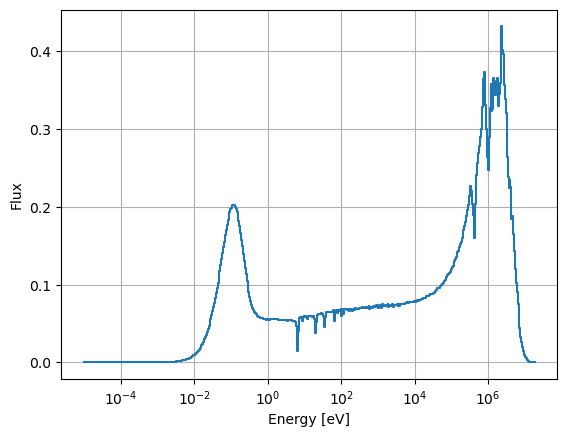

In [11]:
spectrum = sp.get_tally(name='Flux_spectrum')
energy_filter = spectrum.filters[0]
energy = energy_filter.bins[:, 0]
flux_mean = spectrum.get_values(value='mean').ravel()
flux_uncertainty = spectrum.get_values(value='std_dev').ravel()

fig, a = plt.subplots()
a.plot(energy, flux_mean, drawstyle='steps-post')
a.set_xscale('log')
a.set_xlabel('Energy [eV]')
a.set_ylabel('Flux')
a.grid()
plt.savefig('flux spectrum.png')

In [12]:
# Move the statepoint File
ce_spfile = './statepoint_ce.h5'
os.rename('statepoint.1000.h5', ce_spfile)
# Move the Summary file
ce_sumfile = './summary_ce.h5'
os.rename('summary.h5', ce_sumfile)

In [13]:
sp = openmc.StatePoint(ce_spfile, autolink=False)

# Load the summary file in its new location
su = openmc.Summary(ce_sumfile)
sp.link_with_summary(su)

In [14]:
# Initialize MGXS Library with OpenMC statepoint data
mgxs_lib.load_from_statepoint(sp)

In [15]:
# Create a MGXS File 
mgxs_file = mgxs_lib.create_mg_library(xs_type='macro', xsdata_names=['mix'])

# export to "mgxs.h5"
mgxs_file.export_to_hdf5()

In [16]:
mix_mg = openmc.Material(name='Mix of moderator and fuel', material_id=101)
mix_mg.add_macroscopic('mix') 

materials = openmc.Materials([mix_mg])

# location of the cross sections file
materials.cross_sections = 'mgxs.h5'

# update the model with the multi-group materials
model.materials = materials

/home/joelminj/anaconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=101.
  warn(msg, IDWarning)


In [17]:
model.settings.energy_mode = 'multi-group'

In [18]:
# tallies
tallies = openmc.Tallies()

spectrum_tally = openmc.Tally(name='Flux_spectrum')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']
tallies.append(spectrum_tally)

fission_spectrum_tally = openmc.Tally(name='Fission_spectrum')
fission_spectrum_tally.filters = [energy_filter]
fission_spectrum_tally.scores = ['fission']
tallies.append(fission_spectrum_tally)


model.tallies = tallies

In [19]:
# Run the Multi-Group OpenMC Simulation
statepoint_file = model.run()

[studiojkm:07198] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.studiojkm.1000/jf.0/2646278144/shared_mem_cuda_pool.studiojkm could be created.
[studiojkm:07198] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
      

In [20]:
# Move the StatePoint File
mg_spfile = './statepoint_mg.h5'
os.rename('statepoint.1000.h5', mg_spfile)
# Move the Summary file
mg_sumfile = './summary_mg.h5'
os.rename('summary.h5', mg_sumfile)

# Rename and then load the last statepoint file and keff value
mgsp = openmc.StatePoint(mg_spfile, autolink=False)

# Load the summary file in its new location
mgsu = openmc.Summary(mg_sumfile)
mgsp.link_with_summary(mgsu)

# Get keff
mg_keff = mgsp.keff

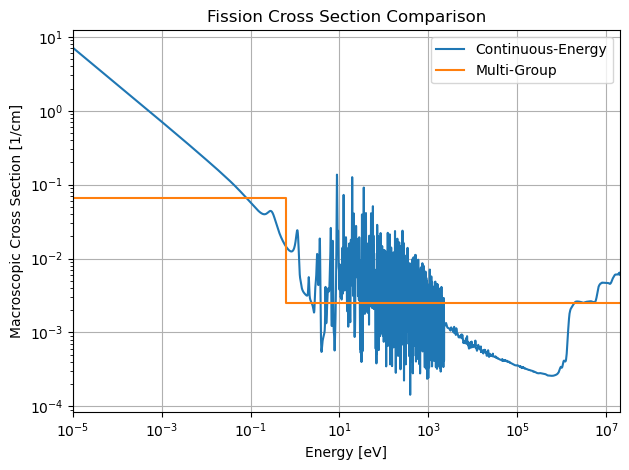

In [21]:
# Plot CE and MG cross sections for 'fission'
fig = openmc.plot_xs(reactions={mix: ['fission']}, axis=None)

# Add MGXS (multi-group) cross sections to the same plot
openmc.plot_xs(reactions={mix_mg: ['fission']}, 
               plot_CE=False, 
               mg_cross_sections='mgxs.h5', 
               axis=fig.axes[0])  # Overlay on the same axis

# Formatting
fig.axes[0].set_title("Fission Cross Section Comparison")
fig.axes[0].set_xlabel("Energy [eV]")
fig.axes[0].set_ylabel("Macroscopic Cross Section [1/cm]")
fig.axes[0].legend(["Continuous-Energy", "Multi-Group"])
fig.axes[0].set_xscale('log')
fig.axes[0].grid(True)

plt.tight_layout()
plt.savefig('Fission Cross Section Comparison.png')
plt.show()

In [22]:
ce_keff = sp.keff

In [23]:
bias = 1.0E5 * (ce_keff - mg_keff)

print('Continuous-Energy keff = {0:1.6f}'.format(ce_keff))
print('Multi-Group keff = {0:1.6f}'.format(mg_keff))
print('bias [pcm]: {0:1.1f}'.format(bias.nominal_value))

Continuous-Energy keff = 1.424360+/-0.000934
Multi-Group keff = 1.424011+/-0.000523
bias [pcm]: 34.8


In [24]:
# Load tallies
sp = openmc.StatePoint('statepoint_mg.h5')  # Use the correct file name if different
flux_tally = sp.get_tally(name='Flux_spectrum')
fission_tally = sp.get_tally(name='Fission_spectrum')

# Extract energy bins and values
energy_bins = flux_tally.filters[0].bins
energies = np.array([b[0] for b in energy_bins] + [energy_bins[-1][1]])  # Bin edges
flux = flux_tally.get_values(value='mean').ravel()
fission = fission_tally.get_values(value='mean').ravel()

# to prevent division by zero
flux = np.where(flux == 0, 1e-20, flux)

# Pointwise macroscopic fission cross section
sigma_f_pointwise = fission / flux

# Bin widths (for integration)
dE = np.diff(energies)

# Integration ranges (based on your group structure)
fast_mask = energies[:-1] >= 0.625  # fast: 0.625 eV – 20 MeV
thermal_mask = energies[:-1] < 0.625  # thermal: 0 – 0.625 eV

# numerical integration
def sigma_f_g(mask):
    num = np.sum(sigma_f_pointwise[mask] * flux[mask] * dE[mask])
    denom = np.sum(flux[mask] * dE[mask])
    return num / denom

sigma_f_fast = sigma_f_g(fast_mask)
sigma_f_thermal = sigma_f_g(thermal_mask)

sigma_f_homogenized =  mgxs_lib.get_mgxs(mix, 'fission').get_xs(nuclides='total', xs_type='macro')

# Print the table
print("Table: Results")
print("| Parameter       | eq. 1 (Analytical) | OpenMC MGXS |")
print("|-----------------|--------------------|-------------|")
print(f"| Σ_f^T (Thermal) | {sigma_f_thermal:.6e} | {sigma_f_homogenized[1]:.6e} |")
print(f"| Σ_f^F (Fast)    | {sigma_f_fast:.6e} | {sigma_f_homogenized[0]:.6e} |")

Table: Results
| Parameter       | eq. 1 (Analytical) | OpenMC MGXS |
|-----------------|--------------------|-------------|
| Σ_f^T (Thermal) | 6.661681e-02 | 6.661681e-02 |
| Σ_f^F (Fast)    | 2.533659e-03 | 2.533659e-03 |
